## Programming Exercise 9

### Setup
This loads the required modules. No other modules are necessary to successfully finish this exercise.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, img_as_float, feature, data, transform, filters
from utils import plot_blobs

### 9.1 Blob Detection

#### 9.1.1 

Load the image `hubble.png` from the `resources` folder, convert it to floating point format and transform the color space to grayscale. Display the image.

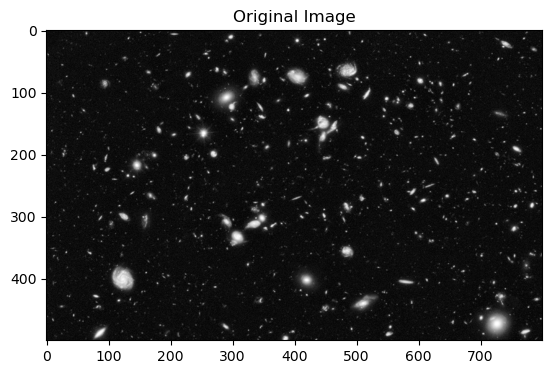

In [2]:
img=color.rgb2gray(img_as_float(io.imread('./resources/hubble.png')))

plt.imshow(img,cmap='gray')
plt.title("Original Image")
plt.show()

#### 9.1.2

Calculate the Difference of Gaussians (DoG) filtered image for three scales $\sigma$ and display the results. Select the scales such that small, medium and large details become visible.

*Hints: The `filters.gaussian` function ([docs](https://scikit-image.org/docs/stable/api/skimage.filters.html#skimage.filters.gaussian)) might be useful. Plot the absolute value of the DoG-filtered images.*

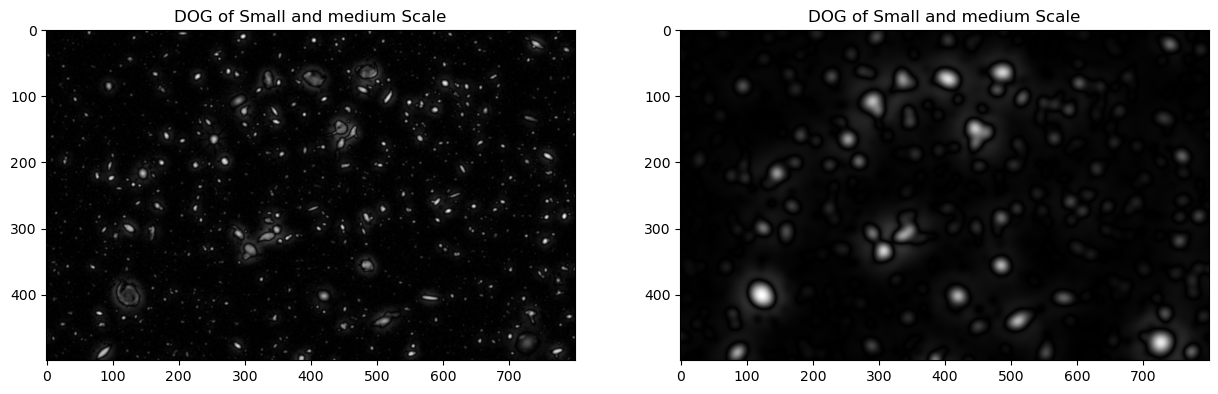

In [3]:

scale_small_img=filters.gaussian(img,sigma=1)
scale_medium_img=filters.gaussian(img,sigma=6)
scale_large_img=filters.gaussian(img,sigma=20)
dog_small_medium=scale_small_img-scale_medium_img
dog_medium_large=scale_medium_img-scale_large_img
fig,ax=plt.subplots(1,2,figsize=(15,15))
ax[0].imshow(np.abs(dog_small_medium),cmap='gray')
ax[0].set_title("DOG of Small and medium Scale")
ax[1].imshow(np.abs(dog_medium_large),cmap='gray')
ax[1].set_title("DOG of Small and medium Scale")
plt.show()


#### 9.1.3

Implement a function `detect_blobs(image, sigma_min, k, levels, threshold)` that performs a blob detection using the Difference of Gaussians to approximate the Laplacian of Gaussian (LoG) blob detector filter. Thereby, `sigma_min` defines the smallest $\sigma$ of the scale-space, `k` defines the ratio to the next $\sigma_{i+1} = k\sigma_{i}$, `levels` defines the number of scales in the scale-space and threshold defines a threshold for blob detection.

Proceed as follows:
1. Define a list of sigmas based on $\sigma_i = \sigma_\text{min} \cdot k^i$.
2. Get the scale-space representation of the image for each $\sigma_i$.
3. Calculate the DoG-filtered images among all scales.
4. Use the `feature.peak_local_max` function to find the peaks in the set of DoG-filtered images. Set the given `threshold` as `threshold_abs`, use a $3\times 3\times 3$ footprint and set `exclude_border=False`.
5. Return the detected blobs as a matrix blobs, where each row contains the location and sigma of one blob as [y, x, sigma].

Detect the blobs in the given image. Start with parameters `sigma_min=1`, `k=1.6`, `levels=15` and `threshold=0.1`. Display the image and overlay the detected blobs using the provided `plot_blobs(blobs)` function.

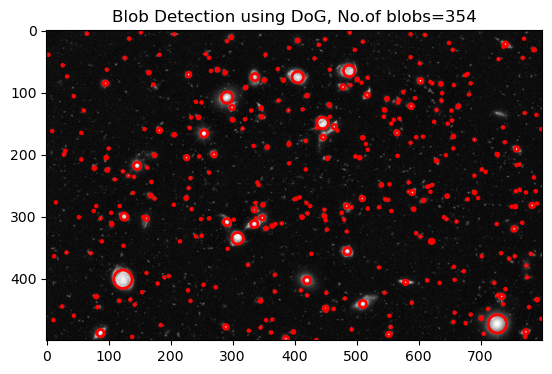

In [48]:
def detect_blobs(image,sigma_min=1,k=1.6,levels=15,threshold=0.1):
    sigma_i=[sigma_min*(k**i) for i in range(levels)]
    gaussian_img=[]
    for sigma_ in sigma_i:
        gaussian_img.append(filters.gaussian(image,sigma=sigma_))
    DOG_imgs=[np.abs(gaussian_img[i]-gaussian_img[i-1]) for i in range(1,len(gaussian_img))]
    DOG_stack=np.stack(DOG_imgs,axis=-1)
    peaks=feature.peak_local_max(DOG_stack,threshold_abs=threshold,footprint=np.ones((3,3,3)),exclude_border=False)
    blobs=[]
    for peak in peaks:
        y,x,sigma_idx=peak
        sigma=sigma_i[sigma_idx]
        blobs.append([y,x,sigma])
    return np.array(blobs)
blobs=detect_blobs(img)
plt.imshow(img,cmap='gray')
plot_blobs(blobs)
plt.title(f"Blob Detection using DoG, No.of blobs={len(blobs)}")
plt.show()
    



### 9.2 Feature Detection

#### 9.2.1 

Load the grayscale images `camera1.png` and `camera2.png` from the `resources` folder and convert them to floating point format. Display the images.

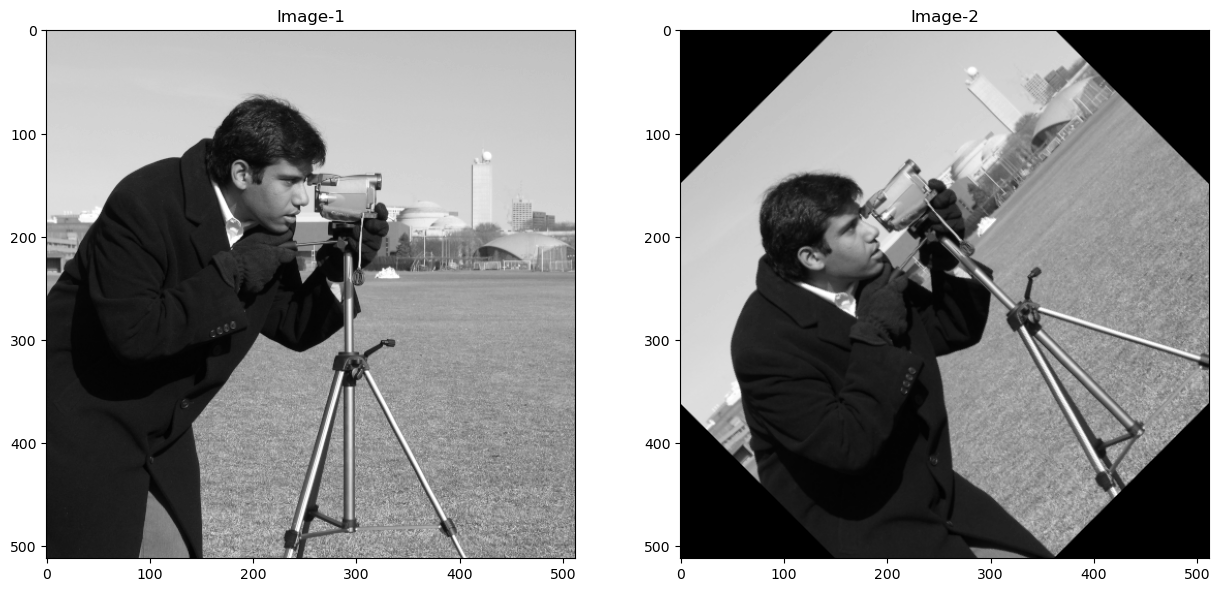

In [4]:
img1=img_as_float(io.imread('./resources/camera1.png'))
img2=img_as_float(io.imread('./resources/camera2.png'))
fig,ax=plt.subplots(1,2,figsize=(15,15))
ax[0].imshow(img1,cmap='gray')
ax[0].set_title("Image-1")
ax[1].imshow(img2,cmap='gray')
ax[1].set_title("Image-2")
plt.show()

#### 9.2.2

Use the SIFT feature detector and descriptor ([docs](https://scikit-image.org/docs/stable/api/skimage.feature.html#skimage.feature.SIFT)) to detect feature keypoints in the two images. Based on the found descriptors, find matching keypoints in both images using the `feature.match-descriptors` function ([docs](https://scikit-image.org/docs/stable/api/skimage.feature.html#skimage.feature.match_descriptors)). Display the matches using the `feature.plot_matches` function ([docs](https://scikit-image.org/docs/stable/api/skimage.feature.html#skimage.feature.plot_matches)).

1104


C:\Users\siva1\AppData\Local\Temp\ipykernel_25304\2468114177.py:9: FutureWarning: `plot_matches` is deprecated since version 0.23 and will be removed in version 0.25. Use `skimage.feature.plot_matched_features` instead.
  feature.plot_matches(ax,img1,img2,sift1.keypoints,sift2.keypoints,matches[::40],only_matches=True)


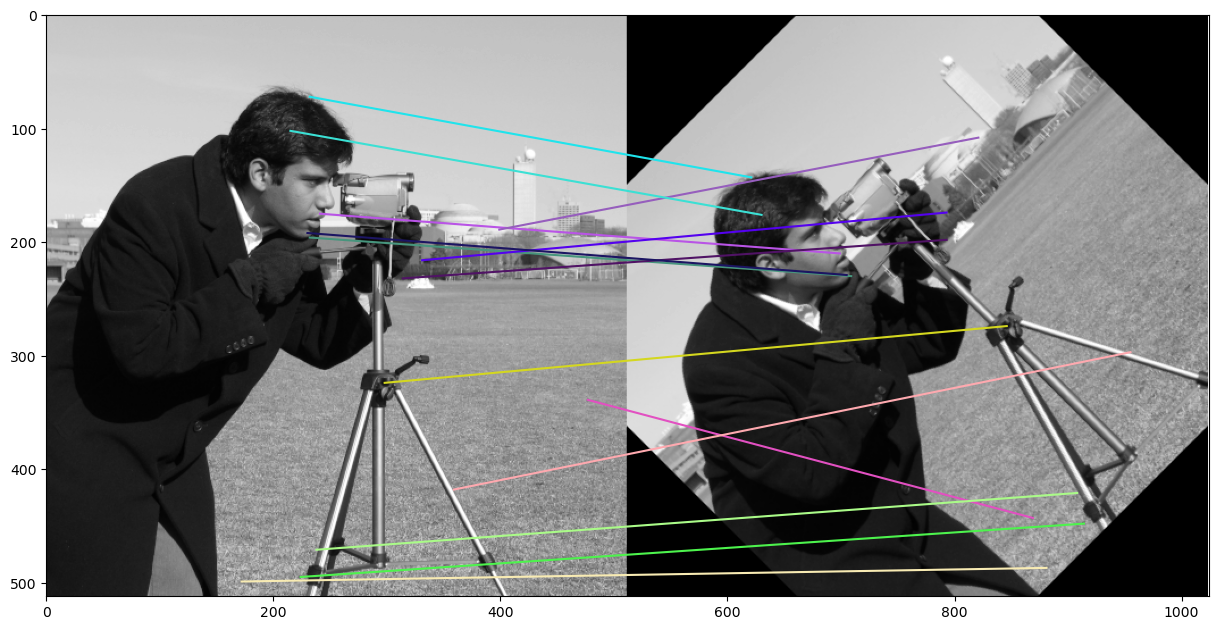

In [7]:
sift1=feature.SIFT()
sift2=feature.SIFT()
sift1.detect_and_extract(img1)
sift2.detect_and_extract(img2)
matches=feature.match_descriptors(sift1.descriptors,sift2.descriptors,max_ratio=0.8)
print(matches.size)
fig,ax=plt.subplots(1,1,figsize=(15,15))
#feature.plot_matched_features(img1,img2,sift1.keypoints,sift2.keypoints,matches,ax,only_matches=True)
feature.plot_matches(ax,img1,img2,sift1.keypoints,sift2.keypoints,matches[::40],only_matches=True)
# for line in ax.lines:
#     line.set_linewidth(0.8)  
plt.show()